In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Gradient Descent

Gradient descent is used to traverse the cost function to the minimum point.

For a linear model:
$$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$
Where the cost function is:
$$J(w, b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 \tag{2}$$

Gradient descent finds the minimum of a function (in this case the cost function) by repeatedly taking small steps downhill along the steepest slope.
It moves in the direction opposite to the function's gradient at the current point.

For linear regression, the algorithm is:
$$repeat \space until \space convergence: \newline 

w = w - \alpha \frac{\partial J(w,b)}{\partial w} \tag{3} \newline
b = b - \alpha \frac{\partial J(w,b)}{\partial b}
$$

where parameters $w$ and $b$ are updated simultaneously. Which means that the partial derivatives for all parameters are calculated before updating any of the parameters

The gradient is defined as:
$$\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum\limits_{i=0}^{m-1}(f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}$$

$$\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}$$


## Implementation

In [3]:
def compute_gradient(x, y, w, b):
    """
    Computes the gradient of the cost function with respect to w and b.

    Args:
        x (numpy array): Input features.
        y (numpy array): Target values.
        w (float): Current weight.
        b (float): Current bias.

    Returns:
        dj_dw (float): Gradient of the cost function with respect to w.
        dj_db (float): Gradient of the cost function with respect to b.
    """
    m = x.shape[0]  # Number of training examples
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b  # Predicted value
        dj_dw += (f_wb - y[i]) * x[i]  # Gradient with respect to w
        dj_db += (f_wb - y[i])

    # Average over all training examples
    dj_dw /= m  
    dj_db /= m

    return dj_dw, dj_db

In [4]:
def compute_cost(x, y, w, b):
    """
    Computes the cost function for linear regression.
    
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    
    Returns
        total_cost (float): The cost of using w,b as the parameters for linear regression
               to fit the data points in x and y
    """
    m = x.shape[0]  # Number of training examples

    cost_sum = 0

    for i in range(m):
        f_wb = w * x[i] + b  # The predicted value for the i-th example
        cost = (f_wb - y[i]) ** 2  # Squared error for the i-th example
        cost_sum += cost  # Accumulate the cost
    total_cost = cost_sum / (2 * m)  # Average cost over all examples

    return total_cost

Let's model housing prices given the size of the house. For this example, there are only two data points.

| Size (1000 sqft)     | Price (1000s of dollars) |
| -------------------| ------------------------ |
| 1                 | 300                      |
| 2                  | 500                      |


In [5]:
x_train = np.array([1.0, 2.0])   #features
y_train = np.array([300.0, 500.0])   #target value

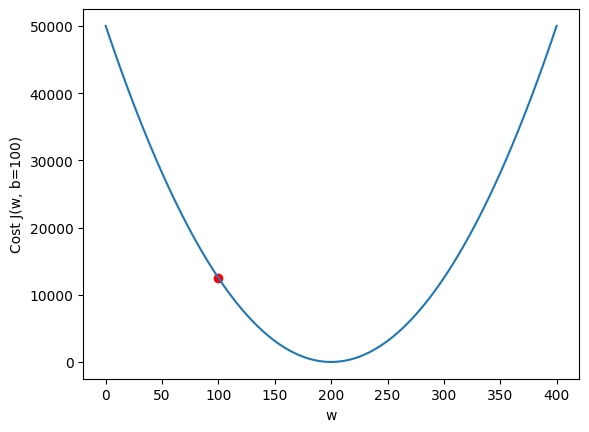

In [ ]:
b = 100
w_range = np.linspace(0, 400, num=100) 
costs = [compute_cost(x_train, y_train, w, b) for w in w_range]


neg_grad, _ = compute_gradient(x_train, y_train, 100, b)
zero_grad, _ = compute_gradient(x_train, y_train, 200, b)
pos_grad, _ = compute_gradient(x_train, y_train, 300, b)




plt.plot(w_range, costs)
plt.xlabel('w')
plt.ylabel('Cost J(w, b=100)')
plt.scatter(100, compute_cost(x_train, y_train, 100, b), color='red', label=f'dJ/dw={neg_grad:.2f}')
